In [298]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from river import stream, tree, metrics, imblearn, ensemble
from sklearn.metrics import classification_report, confusion_matrix

In [299]:
df = pd.read_csv("hrtu_2.csv", header=None)
df.head()

,0,1,2,3,4,5,6,7,8
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


In [300]:
print("Null values:",df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Null values: 0    0
1    0
2    0
3    0
4    0
5    0
6    0
7    0
8    0
dtype: int64
Duplicates: 0


In [301]:
print(df.describe())
print(df.info())

                  0             1             2             3             4  \
count  17898.000000  17898.000000  17898.000000  17898.000000  17898.000000   
mean     111.079968     46.549532      0.477857      1.770279     12.614400   
std       25.652935      6.843189      1.064040      6.167913     29.472897   
min        5.812500     24.772042     -1.876011     -1.791886      0.213211   
25%      100.929688     42.376018      0.027098     -0.188572      1.923077   
50%      115.078125     46.947479      0.223240      0.198710      2.801839   
75%      127.085938     51.023202      0.473325      0.927783      5.464256   
max      192.617188     98.778911      8.069522     68.101622    223.392141   

                  5             6             7             8  
count  17898.000000  17898.000000  17898.000000  17898.000000  
mean      26.326515      8.303556    104.857709      0.091574  
std       19.470572      4.506092    106.514540      0.288432  
min        7.370432     -3.13927

In [302]:
df.columns = [
    "pf_mean",
    "pf_stdev",
    "pf_skew",
    "pf_kurt",
    "dm_mean",
    "dm_stdev",
    "dm_skew",
    "dm_kurt",
    "is_candidate"
]
df.head()

,pf_mean,pf_stdev,pf_skew,pf_kurt,dm_mean,dm_stdev,dm_skew,dm_kurt,is_candidate
0,140.562500,55.683782,-0.234571,-0.699648,3.199833,19.110426,7.975532,74.242225,0
1,102.507812,58.882430,0.465318,-0.515088,1.677258,14.860146,10.576487,127.393580,0
2,103.015625,39.341649,0.323328,1.051164,3.121237,21.744669,7.735822,63.171909,0
3,136.750000,57.178449,-0.068415,-0.636238,3.642977,20.959280,6.896499,53.593661,0
4,88.726562,40.672225,0.600866,1.123492,1.178930,11.468720,14.269573,252.567306,0


### Hoeffding Tree Classification

In [303]:
model = tree.HoeffdingTreeClassifier(
    grace_period=20,
    delta=1e-7,
    leaf_prediction='nba',   
    split_criterion='hellinger'
)

In [304]:
metric = metrics.F1()

dataset = stream.iter_pandas(
    df.drop('is_candidate', axis=1),
    df['is_candidate']
)

In [305]:
y_true = []
y_pred_list = []
cm_1 = metrics.ConfusionMatrix()
warmup=300
i=0

for x, y in dataset:
    y_pred = model.predict_one(x)
    if y_pred is None:
        y_pred = 0

    model.learn_one(x, y)
    
    if y == 1:
        model.learn_one(x, y) 

    if i > warmup:        
        metric.update(y, y_pred)
        cm_1.update(y, y_pred)
        y_true.append(y)
        y_pred_list.append(y_pred)
    

    i += 1

In [306]:
print(len(y_true), len(y_pred_list))

17597 17597


              precision    recall  f1-score   support

           0       0.99      0.98      0.98     15975
           1       0.79      0.89      0.83      1622

    accuracy                           0.97     17597
   macro avg       0.89      0.93      0.91     17597
weighted avg       0.97      0.97      0.97     17597

[[15587   388]
 [  185  1437]]


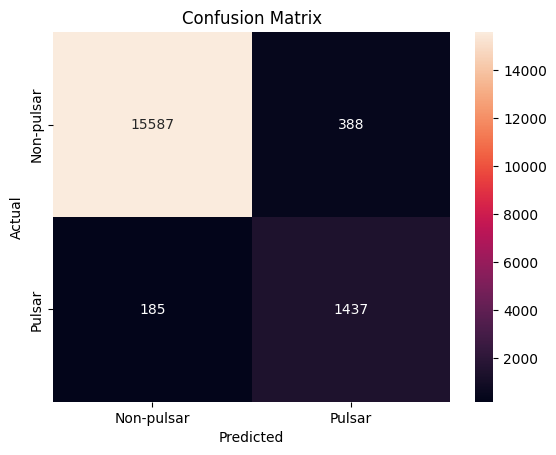

In [307]:
cm_2 = confusion_matrix(y_true, y_pred_list)
print(classification_report(y_true, y_pred_list))
print(confusion_matrix(y_true, y_pred_list))
plt.figure()
sns.heatmap(cm_2, annot=True, fmt='d',
            xticklabels=['Non-pulsar', 'Pulsar'],
            yticklabels=['Non-pulsar', 'Pulsar'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()